<a href="https://colab.research.google.com/github/352tooley/352tooley.github.io/blob/main/Stable_Diffusion_with_diffusers_(text2img%2C_img2img).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# @title Install libraries
# @markdown This cell will take a while because you have to download multiple libraries

!pip install transformers scipy ftfy "ipywidgets>=7,<8"
!git clone https://github.com/huggingface/diffusers.git
!pip install git+https://github.com/huggingface/diffusers.git
!cd diffusers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.7 MB/s eta 0:00:00
Cloning into 'diffusers'...
remote: Enumerating objects: 103070, done.
remote: Counting objects: 100% (701/701), done.
remote: Compressing objects: 100% (371/371), done.
remote: Total 103070 (delta 570), reused 328 (delta 328), pack-reused 102369 (from 4)
Receiving objects: 100% (103070/103070), 77.52 MiB | 14.53 MiB/s, done.
Resolving deltas: 100% (75986/75986), done.
  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-3qrnl1tm
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-3qrnl1tm
  Resolved https://github.com/huggingface/diffusers.git to commit 67ffa7031e5a4bf0991b692a424e36ca59e64ec9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel f

In [4]:
# @title Login in Hugging Face
# @markdown Login in hugginggace and take in account setting access token https://huggingface.co/ .

# @markdown And in this link https://huggingface.co/CompVis/stable-diffusion-v1-4 you must accept the agreement on the use of this model (check the box).
from huggingface_hub import notebook_login
notebook_login()

In [8]:
# @title Import libraries and define things
import os
import torch
import shutil
from PIL import Image
from torch import autocast
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from diffusers import StableDiffusionPipeline
from diffusers import StableDiffusionImg2ImgPipeline
pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4", variant="fp16", torch_dtype=torch.float16, token=True).to("cuda")
pipeimg = StableDiffusionImg2ImgPipeline.from_pretrained("CompVis/stable-diffusion-v1-4", variant="fp16", torch_dtype=torch.float16, token=True).to("cuda")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

safety_checker/model.fp16.safetensors:   0%|          | 0.00/608M [00:00<?, ?B/s]

text_encoder/model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

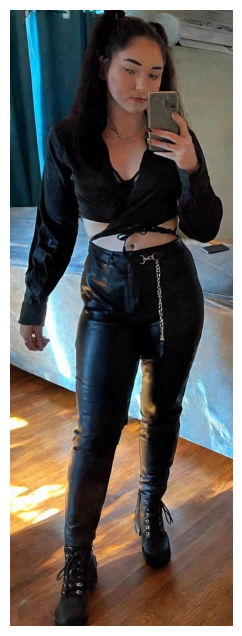

In [29]:
#@title (Run after from here to make changes)
# @markdown Your prompt and size image
PROMPT = "person sitting" #@param {type:"string"}
# @markdown i recommend use small size of image because Free Colab don't have more GPU
HEIGHT = 1621 #@param {type:"integer"}
WIDTH = 585 #@param {type:"integer"}
# @markdown Number of example
EXAMPLES = 1 #@param {type:"integer"}
# @markdown Number of step (recommend 50-100)
STEPS = 50 #@param {type:"integer"}
GUIDANCE_SCALE = 7.5 #@param {type:"number"}
# @markdown for image2image generating
STRENGTH = 0.2 #@param {type:"number"}
INIT_IMAGE = "/content/drive/MyDrive/character.PNG" #@param {type:"string"}
#SAVE_DIR = ""
import numpy as np # Import numpy
import torch # Import torch

if not PROMPT.strip(): #если строка промпта пустая
  print("Please write your prompt")
else: #если не пустая
  for i in range(EXAMPLES): #кол-во примеров
    if not INIT_IMAGE.strip(): #если изображение пусто
      try:
        shutil.rmtree(f'{PROMPT}') #Удаляет папку если она есть
      except FileNotFoundError:
        pass
      os.mkdir(f'{PROMPT}')
      with autocast("cuda"):
        plt.figure(figsize=(8,8))
        image = pipe(PROMPT, num_inference_steps=STEPS, height=HEIGHT, width=WIDTH, guidance_scale=GUIDANCE_SCALE).images[0]
        image.save(f'{PROMPT}/test{i}.png')
        imgi = mpimg.imread(f'{PROMPT}/test{i}.png')
        imgplot = plt.imshow(imgi)
        plt.axis('off')
        plt.show()
    else: #если изображение есть
      init_image = Image.open(INIT_IMAGE).convert("RGB")
      init_image = init_image.resize((WIDTH, HEIGHT))
      # Convert PIL Image to NumPy array and then to PyTorch Tensor
      init_image_np = np.array(init_image)
      init_image_tensor = torch.from_numpy(init_image_np).permute(2, 0, 1).float() / 255.0 # Convert to C, H, W and normalize
      init_image_tensor = init_image_tensor.unsqueeze(0).to("cuda") # Add batch dimension and move to GPU

      prompt_save = "init image__" + PROMPT
      try:
        shutil.rmtree(f'{prompt_save}')
      except FileNotFoundError:
        pass
      os.mkdir(f'{prompt_save}')
      with autocast("cuda"):
        plt.figure(figsize=(8,8))
        # Pass the PyTorch Tensor to pipeimg
        image = pipeimg(PROMPT, image=init_image, strength=STRENGTH, num_inference_steps=STEPS, guidance_scale=GUIDANCE_SCALE).images[0]
        image.save(f'{prompt_save}/test{i}.png')
        imgi = mpimg.imread(f'{prompt_save}/test{i}.png')
        imgplot = plt.imshow(imgi)
        plt.axis('off')
        plt.show()

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
from PIL import Image

INIT_IMAGE = "/content/drive/MyDrive/character.PNG" # Make sure this path is correct
WIDTH = 512
HEIGHT = 512

try:
    init_image = Image.open(INIT_IMAGE).convert("RGB")
    init_image = init_image.resize((WIDTH, HEIGHT))
    print(f"Image type after processing: {type(init_image)}")
    print(f"Image format: {init_image.format}")
    print(f"Image mode: {init_image.mode}")
except FileNotFoundError:
    print(f"Error: The file '{INIT_IMAGE}' was not found.")
except Exception as e:
    print(f"An error occurred while processing the image: {e}")

Image type after processing: <class 'PIL.Image.Image'>
Image format: None
Image mode: RGB
